In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import os
os.environ["CUDA_VISIBLE_DEVICES"] = "1"

In [3]:
import os
import math
import random
import numpy as np
import torch as ch
from glob import glob
from copy import deepcopy
from collections import Counter
from IPython.display import display

import sys
sys.path.append("../src/")
import utils
import matplotlib.pyplot as plt
from robustness_analyzer import RobustnessAnalyzer


from pytorch3d.io import load_obj 

/mnt/xfs/home/hdriss/vision/torchvision/io/image.py:14: UserWarning: Failed to load image Python extension: ''If you don't plan on using image functionality from `torchvision.io`, you can ignore this warning. Otherwise, there might be something wrong with your environment. Did you have `libjpeg` or `libpng` installed before building `torchvision` from source?
  warn(
/mnt/xfs/home/hdriss/conda_envs/torch3d/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


### Camera Perturbation

In [5]:
data_dir = "../data"

# Envmap(s) we're using during optimization (one or more)
max_envs = 5
envmap_paths = glob(os.path.join("../data", "environments_road/*"))
envmap_paths = envmap_paths[::len(envmap_paths)//(max_envs-1)]
print("#environments used:", len(envmap_paths))

true_class = 'container ship, containership, container vessel'
target_class = true_class
 
object_dir = "dredger"

params_to_optimize = ["camera"]

raster_settings = {
    "image_size": 224, # image resolution (image_size, image_size, 3)
    "bin_size": 16,  # Controls spatial partitioning for rasterization - larger values use less memory but may be slower
    "max_faces_per_bin": 100_000,  # Maximum faces per spatial bin - increase for complex meshes, decrease to save memory
}

kwargs = {
    "obj_path": os.path.join(data_dir, object_dir, "dredger.obj"),
    "texture_path": None,
    "envmap_paths": envmap_paths,
    "target_class": target_class,
    "batch_size": 4,  # How many different viewpoints we're optimizing in parallel (* #Environments)
    "params_to_optimize": params_to_optimize,
    "targeted": target_class!=true_class,
    "positive_z": True, # constraints camera z>0 (positive elevation)
    "raster_settings": raster_settings
}

robust_analyzer = RobustnessAnalyzer(**kwargs)

#### Run optimization: This will generate num_runs*batch_size viewpoints
num_runs = 50
num_iterations = 50
results_camera = robust_analyzer.run(num_runs, num_iterations, lr=5e-3)

#environments used: 5


Loss: 1.32 - Class: container ship,... - 'adv acc': 8/20 - Avg Prob: 0.5596 - LR: 5.00e-03: 100%|█| 50/50 [00:16<0
Loss: 0.55 - Class: container ship,... - 'adv acc': 3/20 - Avg Prob: 0.6424 - LR: 5.00e-03: 100%|█| 50/50 [00:15<0
Loss: 3.24 - Class: container ship,... - 'adv acc': 14/20 - Avg Prob: 0.1769 - LR: 5.00e-03: 100%|█| 50/50 [00:15<
Loss: 1.90 - Class: container ship,... - 'adv acc': 7/20 - Avg Prob: 0.4387 - LR: 5.00e-03: 100%|█| 50/50 [00:15<0
Loss: 0.82 - Class: container ship,... - 'adv acc': 2/20 - Avg Prob: 0.5618 - LR: 5.00e-03: 100%|█| 50/50 [00:15<0
Loss: 2.53 - Class: container ship,... - 'adv acc': 12/20 - Avg Prob: 0.3178 - LR: 5.00e-03: 100%|█| 50/50 [00:16<
Loss: 2.66 - Class: container ship,... - 'adv acc': 11/20 - Avg Prob: 0.3047 - LR: 5.00e-03: 100%|█| 50/50 [00:15<
Loss: 1.25 - Class: container ship,... - 'adv acc': 4/20 - Avg Prob: 0.4164 - LR: 5.00e-03: 100%|█| 50/50 [00:15<0
Loss: 0.48 - Class: container ship,... - 'adv acc': 1/20 - Avg Prob: 0.7082 - LR

KeyboardInterrupt: 

In [6]:
# Recover optimization data in case of an interrupted run
results_camera = robust_analyzer.get_current_results()

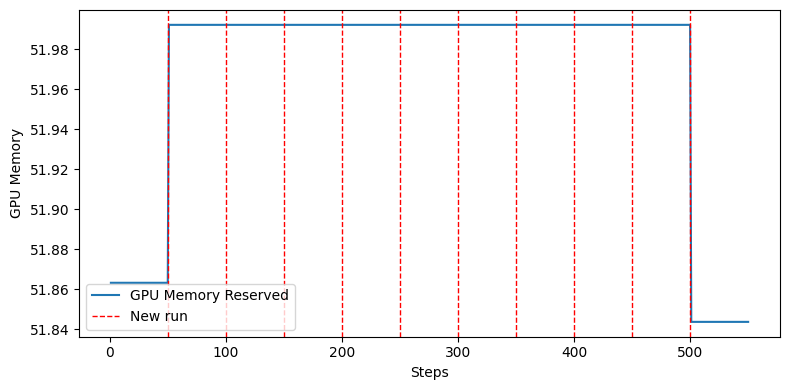

In [7]:
interval = num_iterations

fig = plt.figure(figsize=(8, 4))
plt.plot(range(1, len(results_camera["gpu_memory_reserved"])+1), results_camera["gpu_memory_reserved"], label="GPU Memory Reserved")
num_effective_runs = len(results_camera)

for i in range(1, num_effective_runs):
    if i == 1:
        plt.axvline(x=i * interval, color='red', linestyle='--', linewidth=1, label='New run')
    else:
        plt.axvline(x=i * interval, color='red', linestyle='--', linewidth=1)

plt.xlabel("Steps")
plt.ylabel("GPU Memory")
plt.legend()
plt.tight_layout()
plt.show()

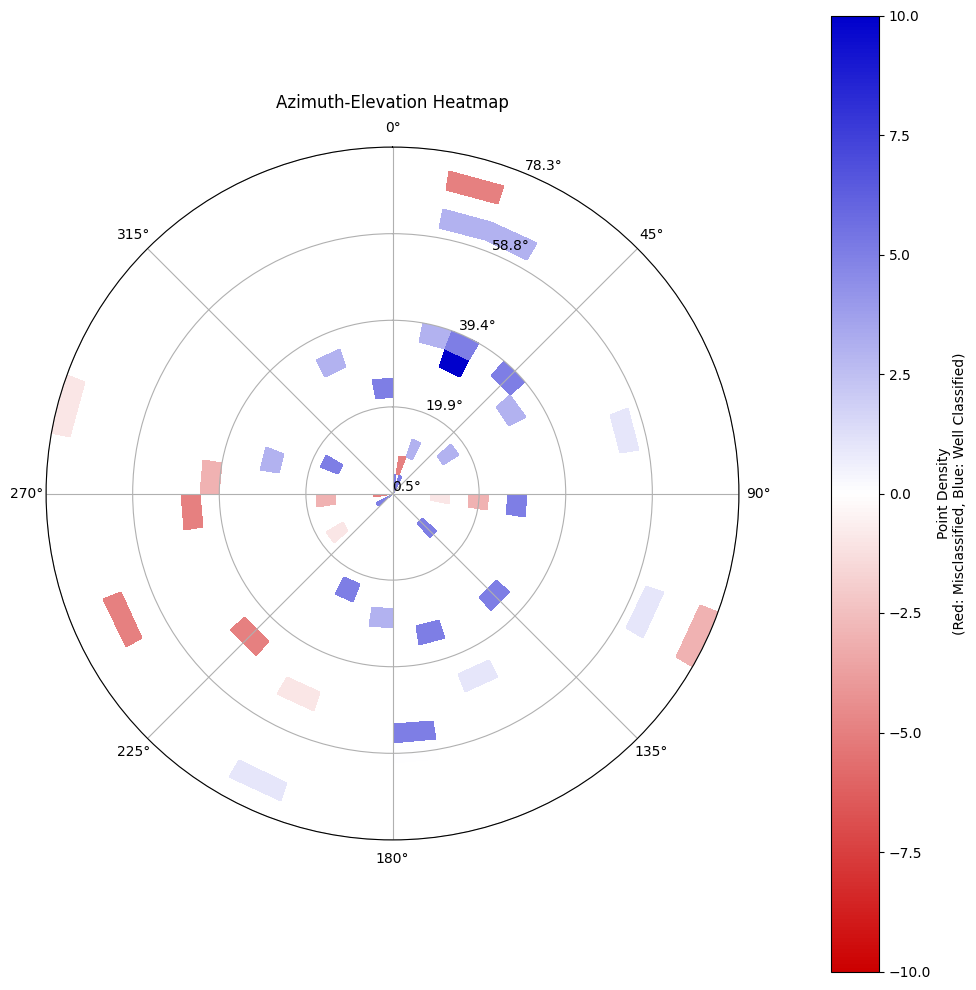

In [8]:
labels_correct = ch.stack(results_camera["final_logits"]).reshape(-1, 1000).argmax(1) == utils.get_idx(true_class)

camera_positions = ch.stack([x["camera"] for x in results_camera["final_scene_params"]]).reshape(-1, 3)\
                        .repeat_interleave(len(envmap_paths) or 1, dim=0)
utils.visualize_positions_polar(camera_positions, labels_correct)

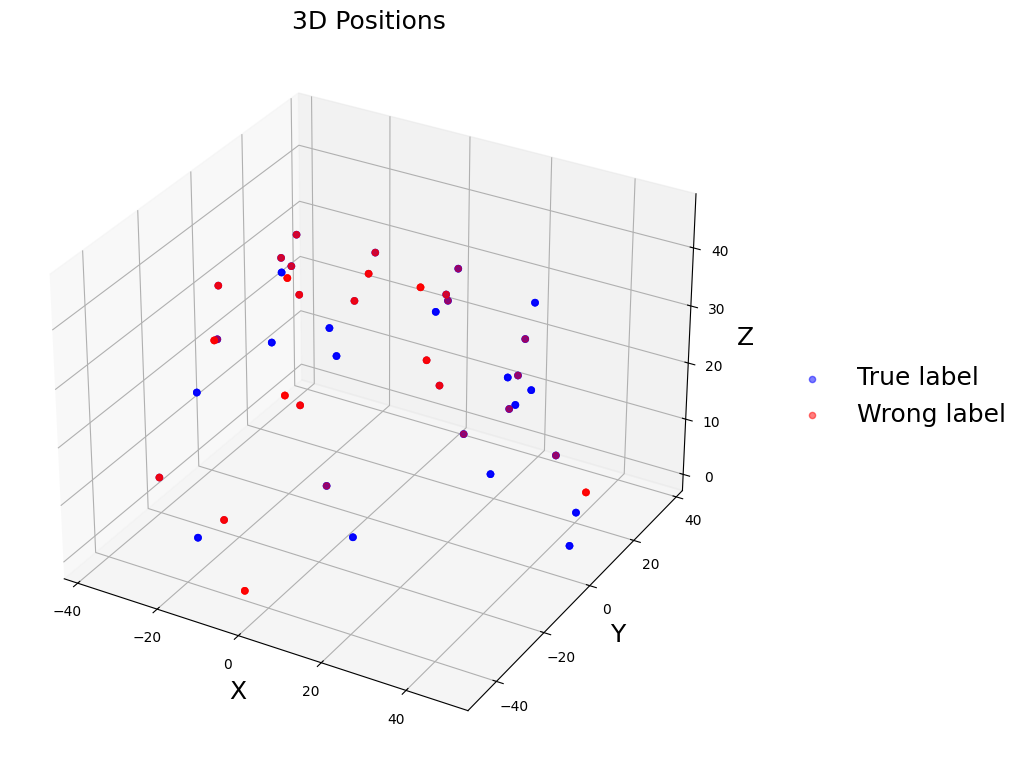

In [9]:
utils.visualize_positions_with_distributions(camera_positions, labels_correct, mode="3d")

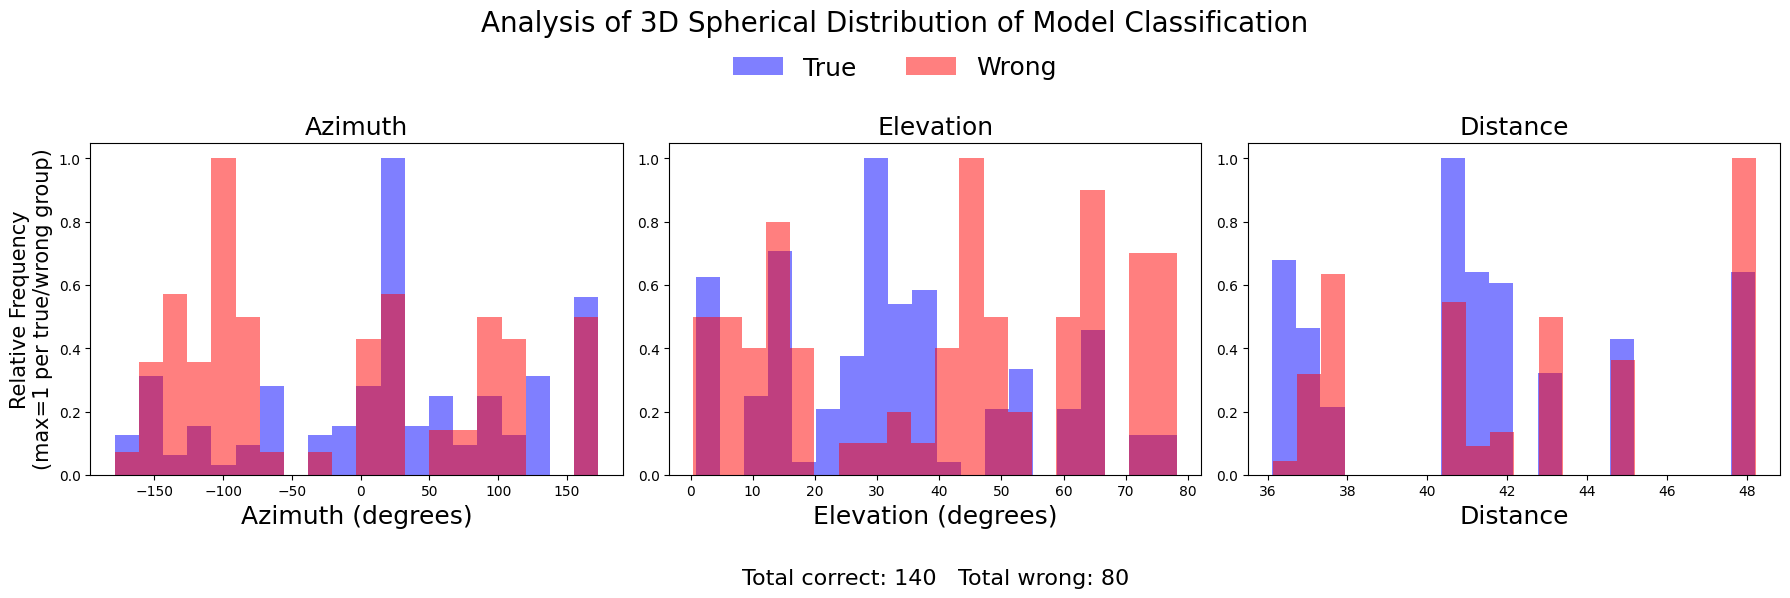

In [10]:
utils.visualize_positions_with_distributions(camera_positions, labels_correct, mode="distributions")

If we want to re-render a specific output we can do it this way, here showing specific examples from the problematic areas from the distribution for Azimuth

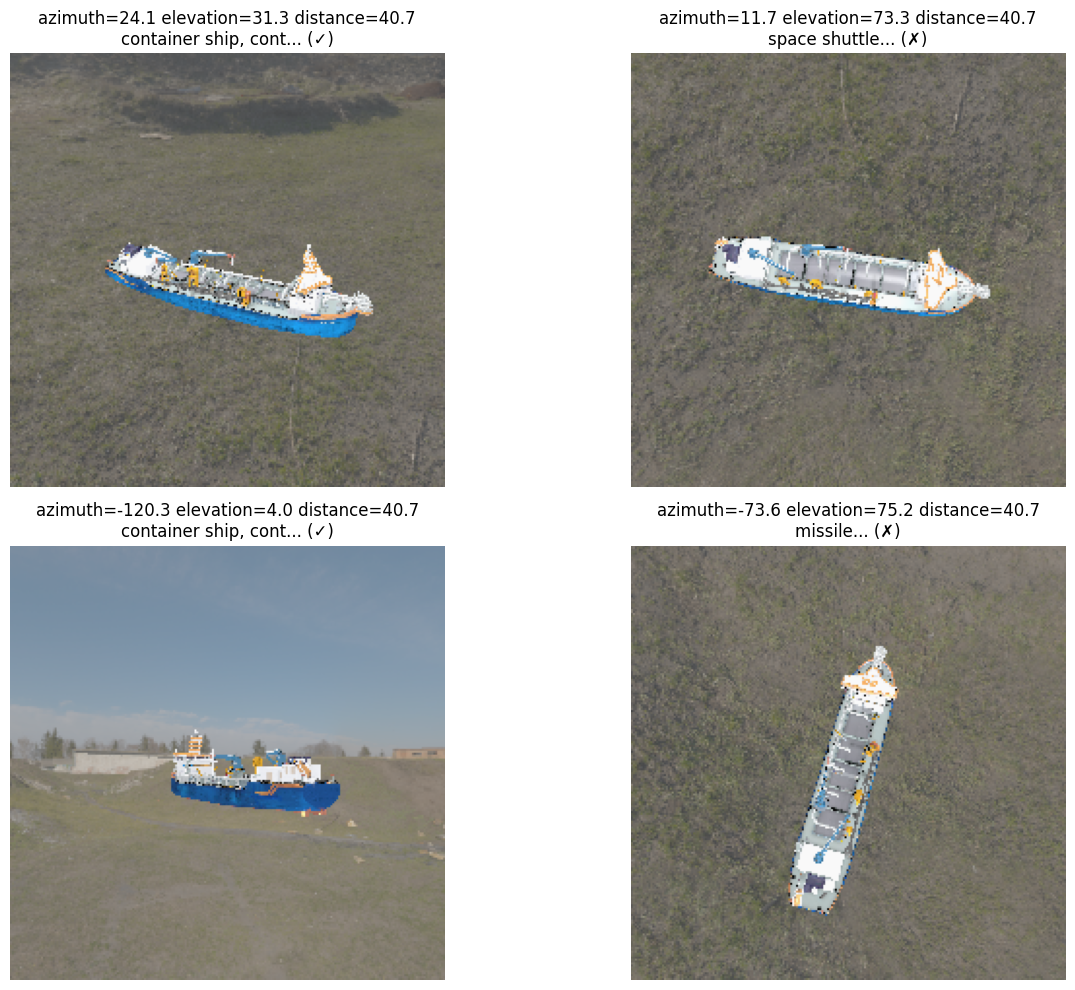

In [11]:
utils.display_rendered_images(
    robust_analyzer,
    results=results_camera,
    image_res=224,
    run_index=0,
    env_index=0 
)

In [12]:
utils.create_logits_comparison_table(all_results={"camera": results_camera})